# 🌾 Sugarcane Yield Prediction using Machine Learning

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/)

## 📌 Project Overview
This notebook implements an end-to-end Machine Learning pipeline for **Sugarcane Yield Prediction** using both **Regression** (predicting precise crop yield in tons/hectare) and **Classification** (classifying yield performance into High vs Low Yield categories).

---

## 🛠️ Key Machine Learning Requirements Implemented:
1. **Regression Algorithms**:
   - Linear Regression
   - Polynomial Regression (Degree 2 Interaction)
   - Ridge Regression ($L_2$ Regularization)
   - Lasso Regression ($L_1$ Regularization)
2. **Classification Algorithms**:
   - Logistic Regression
   - K-Nearest Neighbors (KNN)
3. **Model Evaluation & Metrics**:
   - Train/Test Split (80/20) & 5-Fold Cross-Validation (K-Fold & Stratified K-Fold)
   - Regression Metrics: Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), $R^2$ Score
   - Classification Metrics: Confusion Matrix Heatmaps, Precision, Recall, F1-Score, ROC-AUC Curve
4. **Feature Engineering & Preprocessing**:
   - Missing data detection & median/mode imputation
   - One-Hot Encoding for categorical features (`Soil_Type`)
   - Feature Scaling (`StandardScaler`)
   - Feature Engineering (Total water availability, Water-to-Temperature ratio, Fertilizer efficiency ratio)
5. **Pickle Model Serialization**:
   - Saving trained models, scalers, encoders, and full `sklearn` pipelines into `.pkl` files
   - Complete inference demonstration script to load `.pkl` and predict yield on custom input parameters!

In [1]:
# Google Colab Setup (Uncomment if running on Google Colab)
# from google.colab import drive
# drive.mount('/content/drive')

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# SciKit-Learn Utilities
from sklearn.model_selection import train_test_split, cross_val_score, KFold, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression Models & Metrics
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Classification Models & Metrics
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

# Plotting Configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.figsize"] = (9, 5)

print("✅ All required libraries imported successfully!")

✅ All required libraries imported successfully!


---
## 1. 📊 Data Loading & Exploratory Data Analysis (EDA)

We load the dataset containing agricultural features such as soil type, rainfall, irrigation levels, fertilizer application rate, temperature, and total water usage per hectare.

In [18]:
# Load dataset
dataset_path = "datasets/sugarcane_yield_dataset_large.csv"
if not os.path.exists(dataset_path):
    dataset_path = "sugarcane_yield_dataset.csv"

df = pd.read_csv(dataset_path)
print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns\n")

# Display first 5 rows
print("--- First 5 Rows ---")
display(df.head())

# Drop non-predictive Plot_ID if present
if "Plot_ID" in df.columns:
    df = df.drop(columns=["Plot_ID"])

print("\n--- Dataset Summary & Null Count ---")
df.info()

Dataset Loaded: 1000 rows, 8 columns

--- First 5 Rows ---


,Plot_ID,Soil_Type,Rainfall_mm,Irrigation_liters_ha,Fertilizer_kg_ha,Temperature_C,Water_Usage_liters_ha,Yield_tons_ha
0,P1,Clayey,642,1492,207,28,2134,59
1,P2,Loamy,942,1041,224,27,1983,61
2,P3,Clayey,439,2039,334,32,2478,65
3,P4,Clayey,628,2074,172,34,2702,63
4,P5,Loamy,947,925,325,33,1872,59



--- Dataset Summary & Null Count ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Soil_Type              1000 non-null   object
 1   Rainfall_mm            1000 non-null   int64 
 2   Irrigation_liters_ha   1000 non-null   int64 
 3   Fertilizer_kg_ha       1000 non-null   int64 
 4   Temperature_C          1000 non-null   int64 
 5   Water_Usage_liters_ha  1000 non-null   int64 
 6   Yield_tons_ha          1000 non-null   int64 
dtypes: int64(6), object(1)
memory usage: 54.8+ KB


In [12]:
df.head()

,Soil_Type,Rainfall_mm,Irrigation_liters_ha,Fertilizer_kg_ha,Temperature_C,Water_Usage_liters_ha,Yield_tons_ha,Total_Water_ha,Water_Temp_Ratio,Fertilizer_Water_Ratio,High_Yield_Class
0,Clayey,642.0,1492,207,28.0,2134,59,2134.0,76.214258,0.097001,0
1,Loamy,942.0,1041,224,27.0,1983,61,1983.0,73.444417,0.112960,0
2,Clayey,439.0,2039,334,32.0,2478,65,2478.0,77.437476,0.134786,1
3,Clayey,628.0,2074,172,34.0,2702,63,2702.0,79.470565,0.063657,0
4,Loamy,947.0,925,325,33.0,1872,59,1872.0,56.727256,0.173611,0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Soil_Type               1000 non-null   object 
 1   Rainfall_mm             981 non-null    float64
 2   Irrigation_liters_ha    1000 non-null   int64  
 3   Fertilizer_kg_ha        1000 non-null   int64  
 4   Temperature_C           985 non-null    float64
 5   Water_Usage_liters_ha   1000 non-null   int64  
 6   Yield_tons_ha           1000 non-null   int64  
 7   Total_Water_ha          1000 non-null   float64
 8   Water_Temp_Ratio        1000 non-null   float64
 9   Fertilizer_Water_Ratio  1000 non-null   float64
 10  High_Yield_Class        1000 non-null   int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 86.1+ KB


In [17]:
df.sample


<bound method NDFrame.sample of     Soil_Type  Rainfall_mm  Irrigation_liters_ha  Fertilizer_kg_ha  \
0      Clayey        642.0                  1492               207   
1       Loamy        942.0                  1041               224   
2      Clayey        439.0                  2039               334   
3      Clayey        628.0                  2074               172   
4       Loamy        947.0                   925               325   
..        ...          ...                   ...               ...   
995     Sandy       1090.0                  1345               244   
996     Sandy        605.0                   840               305   
997    Clayey        411.0                  1106               219   
998    Clayey        889.0                  1742               318   
999     Loamy        675.0                  1137               165   

     Temperature_C  Water_Usage_liters_ha  Yield_tons_ha  Total_Water_ha  \
0             28.0                   2134          

<Axes: title={'center': 'Top 10 Columns with Missing Values'}>

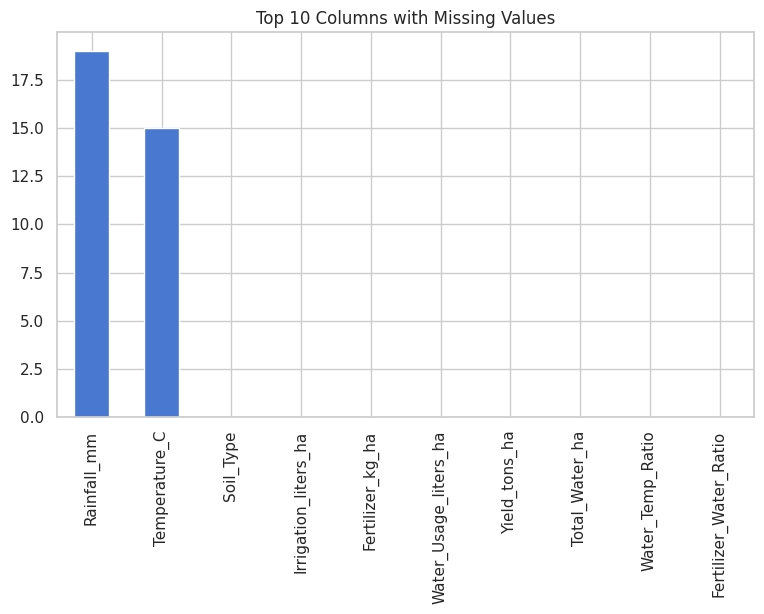

In [14]:
df.isnull().sum().sort_values(ascending=False).head(10).plot(kind='bar', title='Top 10 Columns with Missing Values')

,Rainfall_mm,Irrigation_liters_ha,Fertilizer_kg_ha,Temperature_C,Water_Usage_liters_ha,Yield_tons_ha
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,739.758000,1496.842000,250.038000,29.508000,2236.600000,63.356000
std,204.266768,392.792264,58.018003,2.878928,440.003936,11.544979
min,400.000000,801.000000,150.000000,25.000000,1211.000000,31.000000
25%,560.000000,1169.750000,199.000000,27.000000,1899.000000,55.750000
50%,728.500000,1474.500000,251.000000,30.000000,2220.000000,63.500000
75%,919.250000,1827.000000,302.250000,32.000000,2560.250000,71.000000
max,1099.000000,2199.000000,349.000000,34.000000,3257.000000,96.000000


C:\Users\SHANTANU\AppData\Local\Temp\ipykernel_17116\1422676346.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Soil_Type", palette="crest", ax=axes[1])


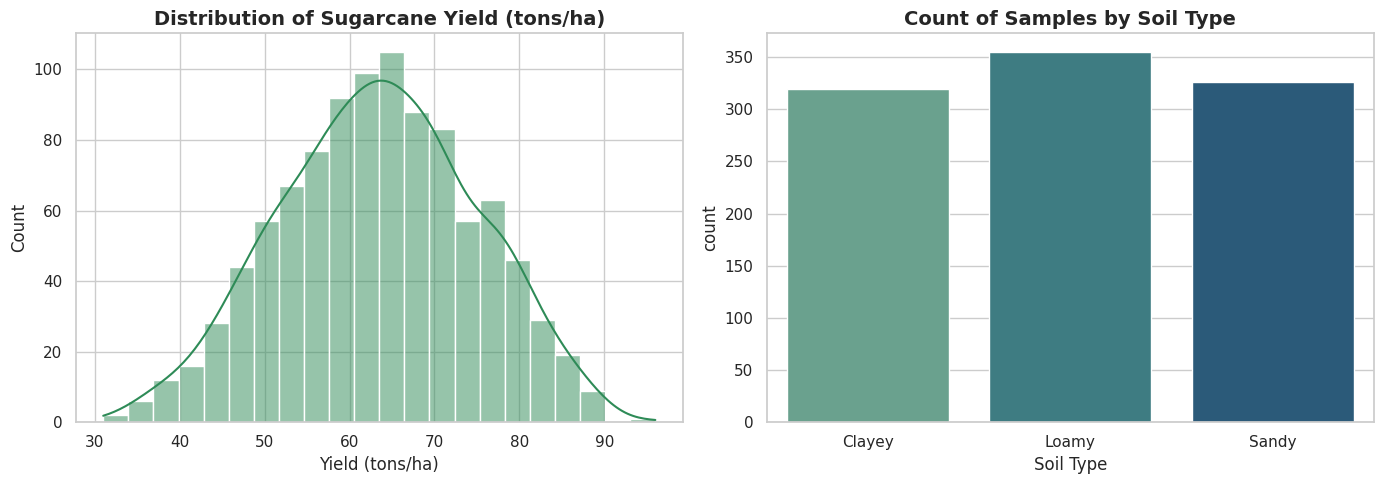

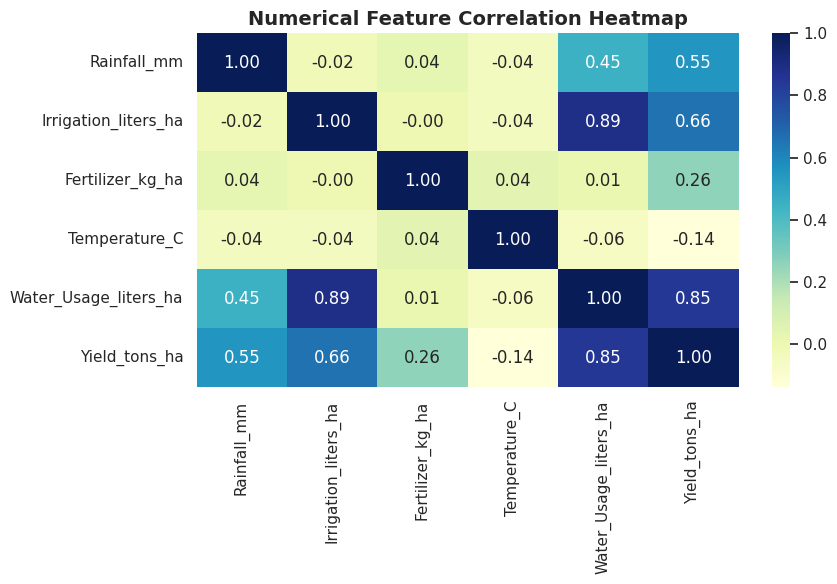

In [3]:
# Summary Statistics
display(df.describe())

# Visualizing Target Yield Distribution & Soil Type count
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["Yield_tons_ha"], kde=True, color="seagreen", ax=axes[0])
axes[0].set_title("Distribution of Sugarcane Yield (tons/ha)", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Yield (tons/ha)")

sns.countplot(data=df, x="Soil_Type", palette="crest", ax=axes[1])
axes[1].set_title("Count of Samples by Soil Type", fontsize=14, fontweight="bold")
axes[1].set_xlabel("Soil Type")

plt.tight_layout()
plt.show()

# Feature Correlation Matrix
plt.figure(figsize=(9, 6))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="YlGnBu", cbar=True)
plt.title("Numerical Feature Correlation Heatmap", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 2. ⚙️ Handling Missing Data & Feature Engineering

1. **Missing Data Handling**: Detect and impute missing values using median imputation for continuous features and mode imputation for categorical features (`SimpleImputer`).
2. **Feature Engineering**:
   - `Total_Water_ha` = $\text{Rainfall\_mm} + \text{Irrigation\_liters\_ha}$
   - `Water_Temp_Ratio` = $\frac{\text{Total\_Water\_ha}}{\text{Temperature\_C}}$
   - `Fertilizer_Water_Ratio` = $\frac{\text{Fertilizer\_kg\_ha}}{\text{Total\_Water\_ha}}$
3. **Categorical Classification Target**: Discretize continuous yield into binary classes:
   - `1`: High Yield ($\ge \text{Median Yield}$)
   - `0`: Low Yield ($< \text{Median Yield}$)

In [4]:
# Inject missing values if dataset is 100% complete to demonstrate imputer capability
missing_before = df.isnull().sum().sum()
if missing_before == 0:
    np.random.seed(42)
    mask_rain = np.random.rand(len(df)) < 0.02
    mask_temp = np.random.rand(len(df)) < 0.02
    df.loc[mask_rain, "Rainfall_mm"] = np.nan
    df.loc[mask_temp, "Temperature_C"] = np.nan
    print(f"Injected sample missing values for demonstration: {df.isnull().sum().to_dict()}")

# Feature Engineering
df["Total_Water_ha"] = df["Rainfall_mm"].fillna(df["Rainfall_mm"].median()) + df["Irrigation_liters_ha"].fillna(df["Irrigation_liters_ha"].median())
df["Water_Temp_Ratio"] = df["Total_Water_ha"] / (df["Temperature_C"].fillna(df["Temperature_C"].median()) + 1e-5)
df["Fertilizer_Water_Ratio"] = df["Fertilizer_kg_ha"].fillna(df["Fertilizer_kg_ha"].median()) / (df["Total_Water_ha"] + 1e-5)

# Classification Target
yield_median = df["Yield_tons_ha"].median()
df["High_Yield_Class"] = (df["Yield_tons_ha"] >= yield_median).astype(int)

print(f"Yield Threshold for Classification: {yield_median:.2f} tons/ha")
print(f"High Yield Class Balance:\n{df['High_Yield_Class'].value_counts()}")

Injected sample missing values for demonstration: {'Soil_Type': 0, 'Rainfall_mm': 19, 'Irrigation_liters_ha': 0, 'Fertilizer_kg_ha': 0, 'Temperature_C': 15, 'Water_Usage_liters_ha': 0, 'Yield_tons_ha': 0}
Yield Threshold for Classification: 63.50 tons/ha
High Yield Class Balance:
High_Yield_Class
0    500
1    500
Name: count, dtype: int64


In [5]:
# Define Features and Targets
X = df.drop(columns=["Yield_tons_ha", "High_Yield_Class"])
y_reg = df["Yield_tons_ha"]
y_cls = df["High_Yield_Class"]

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Define Imputers, Encoders, and Scalers inside ColumnTransformer
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, num_cols),
    ('cat', cat_transformer, cat_cols)
])

print(f"Preprocessing Pipeline Configured!")
print(f"Numerical Features ({len(num_cols)}): {num_cols}")
print(f"Categorical Features ({len(cat_cols)}): {cat_cols}")

Preprocessing Pipeline Configured!
Numerical Features (8): ['Rainfall_mm', 'Irrigation_liters_ha', 'Fertilizer_kg_ha', 'Temperature_C', 'Water_Usage_liters_ha', 'Total_Water_ha', 'Water_Temp_Ratio', 'Fertilizer_Water_Ratio']
Categorical Features (1): ['Soil_Type']


---
## 3. 📈 Regression Models (Linear, Polynomial, Ridge, Lasso)

We fit and evaluate four regression models to predict `Yield_tons_ha`:
1. **Linear Regression**: Ordinary Least Squares baseline model.
2. **Polynomial Regression**: Degree 2 feature expansion to capture non-linear interaction terms.
3. **Ridge Regression**: Linear regression with $L_2$ regularization penalty ($\alpha = 10.0$).
4. **Lasso Regression**: Linear regression with $L_1$ regularization penalty ($\alpha = 0.1$).

Evaluation Metrics: Mean Squared Error (MSE), Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), $R^2$ Score, and 5-Fold Cross Validation.

In [6]:
# Train / Test Split (80/20)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# 1. Linear Regression Pipeline
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])
lr_pipeline.fit(X_train_r, y_train_r)

# 2. Polynomial Regression (Degree 2) Pipeline
poly_preprocessor = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=2, include_bias=False))
])
poly_pipeline = Pipeline(steps=[('preprocessor', poly_preprocessor), ('regressor', LinearRegression())])
poly_pipeline.fit(X_train_r, y_train_r)

# 3. Ridge Regression Pipeline
ridge_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Ridge(alpha=10.0))])
ridge_pipeline.fit(X_train_r, y_train_r)

# 4. Lasso Regression Pipeline
lasso_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', Lasso(alpha=0.1))])
lasso_pipeline.fit(X_train_r, y_train_r)

print("✅ All 4 Regression Pipelines Trained Successfully!")

✅ All 4 Regression Pipelines Trained Successfully!


=== REGRESSION MODEL METRICS COMPARISON ===


,Model,MSE,RMSE,MAE,R2_Test,5-Fold CV R2
0,Linear Regression,22.3087,4.7232,3.6750,0.8275,0.8145
1,Polynomial Reg (Deg 2),57.7228,7.5976,4.5692,0.5537,0.7267
2,Ridge Reg (alpha=10),22.7464,4.7693,3.7126,0.8241,0.8145
3,Lasso Reg (alpha=0.1),22.4249,4.7355,3.6843,0.8266,0.8160


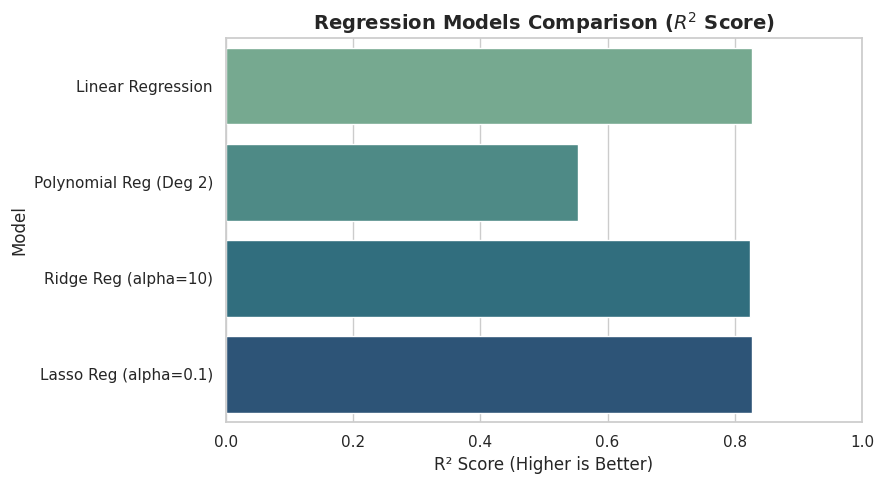

In [7]:
# Evaluation Helper Function
def evaluate_reg_model(name, model, X_tr, y_tr, X_te, y_te):
    y_pred = model.predict(X_te)
    mse = mean_squared_error(y_te, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_te, y_pred)
    r2 = r2_score(y_te, y_pred)
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=kf, scoring='r2').mean()
    
    return {
        "Model": name,
        "MSE": round(mse, 4),
        "RMSE": round(rmse, 4),
        "MAE": round(mae, 4),
        "R2_Test": round(r2, 4),
        "5-Fold CV R2": round(cv_r2, 4)
    }

reg_summary = []
reg_summary.append(evaluate_reg_model("Linear Regression", lr_pipeline, X_train_r, y_train_r, X_test_r, y_test_r))
reg_summary.append(evaluate_reg_model("Polynomial Reg (Deg 2)", poly_pipeline, X_train_r, y_train_r, X_test_r, y_test_r))
reg_summary.append(evaluate_reg_model("Ridge Reg (alpha=10)", ridge_pipeline, X_train_r, y_train_r, X_test_r, y_test_r))
reg_summary.append(evaluate_reg_model("Lasso Reg (alpha=0.1)", lasso_pipeline, X_train_r, y_train_r, X_test_r, y_test_r))

reg_df = pd.DataFrame(reg_summary)
print("=== REGRESSION MODEL METRICS COMPARISON ===")
display(reg_df)

# Plot Regression Comparison
plt.figure(figsize=(9, 5))
sns.barplot(data=reg_df, x="R2_Test", y="Model", hue="Model", palette="crest", legend=False)
plt.title("Regression Models Comparison ($R^2$ Score)", fontsize=14, fontweight="bold")
plt.xlim(0, 1.0)
plt.xlabel("R² Score (Higher is Better)")
plt.tight_layout()
plt.show()

---
## 4. 🎯 Classification Models (Logistic Regression & KNN)

We evaluate models for classifying whether sugarcane yield will be **High Yield** vs **Low Yield**:
1. **Logistic Regression**: Linear binary classifier with probability estimation.
2. **K-Nearest Neighbors (KNN)**: Non-parametric distance-based classifier ($K=7$).

Evaluation Metrics: Accuracy, Precision, Recall, F1-Score, 5-Fold Stratified Cross-Validation, Confusion Matrix Heatmaps, and ROC-AUC Curves.

In [8]:
# Stratified Train/Test Split for Classification
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

# 1. Logistic Regression Pipeline
logreg_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', LogisticRegression(random_state=42))])
logreg_pipeline.fit(X_train_c, y_train_c)

# 2. KNN Classifier Pipeline (k=7)
knn_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', KNeighborsClassifier(n_neighbors=7))])
knn_pipeline.fit(X_train_c, y_train_c)

print("✅ Both Classification Pipelines Trained Successfully!")

✅ Both Classification Pipelines Trained Successfully!


=== CLASSIFICATION MODEL METRICS COMPARISON ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,5-Fold CV ROC-AUC
0,Logistic Regression,0.88,0.8878,0.87,0.8788,0.9468,0.9392
1,KNN (k=7),0.87,0.8700,0.87,0.8700,0.9369,0.9165


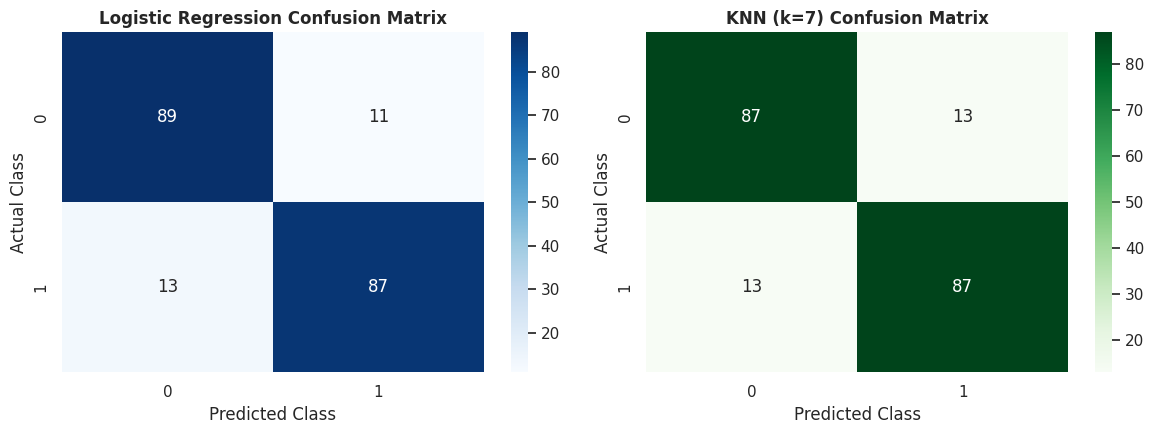

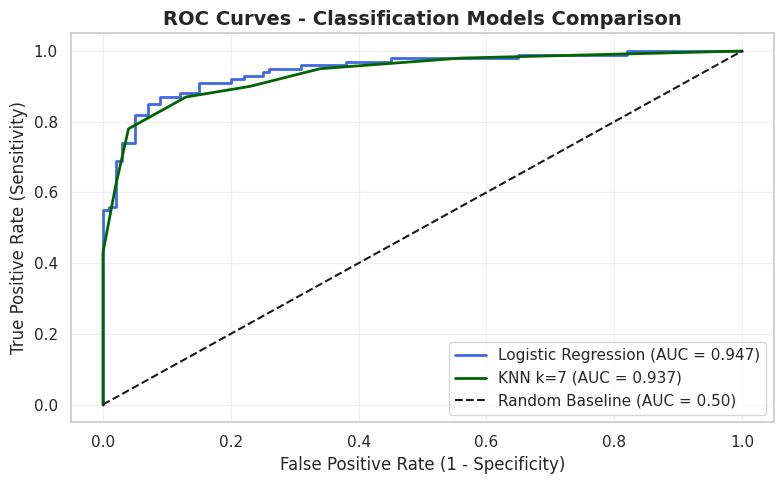

In [9]:
# Classification Evaluation
def evaluate_cls_model(name, model, X_tr, y_tr, X_te, y_te):
    y_pred = model.predict(X_te)
    y_proba = model.predict_proba(X_te)[:, 1]
    
    acc = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec = recall_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    roc_auc = roc_auc_score(y_te, y_proba)
    
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_auc = cross_val_score(model, X_tr, y_tr, cv=skf, scoring='roc_auc').mean()
    cm = confusion_matrix(y_te, y_pred)
    
    return {
        "Model": name, "Accuracy": round(acc, 4), "Precision": round(prec, 4),
        "Recall": round(rec, 4), "F1-Score": round(f1, 4), "ROC-AUC": round(roc_auc, 4),
        "5-Fold CV ROC-AUC": round(cv_auc, 4), "CM": cm, "y_proba": y_proba
    }

logreg_res = evaluate_cls_model("Logistic Regression", logreg_pipeline, X_train_c, y_train_c, X_test_c, y_test_c)
knn_res = evaluate_cls_model("KNN (k=7)", knn_pipeline, X_train_c, y_train_c, X_test_c, y_test_c)

cls_df = pd.DataFrame([{k: v for k, v in r.items() if k not in ['CM', 'y_proba']} for r in [logreg_res, knn_res]])
print("=== CLASSIFICATION MODEL METRICS COMPARISON ===")
display(cls_df)

# Plot Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(logreg_res["CM"], annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title("Logistic Regression Confusion Matrix", fontweight="bold")
axes[0].set_xlabel("Predicted Class")
axes[0].set_ylabel("Actual Class")

sns.heatmap(knn_res["CM"], annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title("KNN (k=7) Confusion Matrix", fontweight="bold")
axes[1].set_xlabel("Predicted Class")
axes[1].set_ylabel("Actual Class")

plt.tight_layout()
plt.show()

# Plot ROC-AUC Curves
plt.figure(figsize=(8, 5))
fpr_log, tpr_log, _ = roc_curve(y_test_c, logreg_res["y_proba"])
fpr_knn, tpr_knn, _ = roc_curve(y_test_c, knn_res["y_proba"])

plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {logreg_res['ROC-AUC']:.3f})", lw=2, color="royalblue")
plt.plot(fpr_knn, tpr_knn, label=f"KNN k=7 (AUC = {knn_res['ROC-AUC']:.3f})", lw=2, color="darkgreen")
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline (AUC = 0.50)')

plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curves - Classification Models Comparison", fontsize=14, fontweight="bold")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 5. 📦 Exporting Model to Pickle (`.pkl`)

We serialize the trained pipelines into `.pkl` format so they can be easily loaded in production web apps or Google Colab environments for real-time inference.

In [10]:
# Save Models to Pickle Files
pickle_reg_path = "sugarcane_model.pkl"
pickle_cls_path = "sugarcane_classifier.pkl"
pickle_pipeline_path = "sugarcane_pipeline.pkl"

# Save best regression model pipeline (Ridge Regression)
with open(pickle_reg_path, 'wb') as f:
    pickle.dump(ridge_pipeline, f)

# Save best classification model pipeline (Logistic Regression)
with open(pickle_cls_path, 'wb') as f:
    pickle.dump(logreg_pipeline, f)

# Save full unified pipeline bundle
pipeline_bundle = {
    "regression_pipeline": ridge_pipeline,
    "classification_pipeline": logreg_pipeline,
    "yield_threshold": yield_median,
    "feature_columns": list(X.columns),
    "num_cols": num_cols,
    "cat_cols": cat_cols
}

with open(pickle_pipeline_path, 'wb') as f:
    pickle.dump(pipeline_bundle, f)

print(f"🎉 Successfully exported trained models to Pickle files!")
print(f"  1. Regression Pipeline:     '{pickle_reg_path}'")
print(f"  2. Classification Pipeline: '{pickle_cls_path}'")
print(f"  3. Complete Unified Bundle: '{pickle_pipeline_path}'")

🎉 Successfully exported trained models to Pickle files!
  1. Regression Pipeline:     'sugarcane_model.pkl'
  2. Classification Pipeline: 'sugarcane_classifier.pkl'
  3. Complete Unified Bundle: 'sugarcane_pipeline.pkl'


---
## 6. 🔮 Predicting Yield from Saved Pickle File

Below is the complete inference code showing how to load the `.pkl` pipeline and predict sugarcane yield for brand new custom input parameters!

In [11]:
# --- INFERENCE DEMO ---
import pickle
import pandas as pd

# Load the saved pickle bundle
with open("sugarcane_pipeline.pkl", "rb") as f:
    saved_model = pickle.load(f)

reg_model = saved_model["regression_pipeline"]
cls_model = saved_model["classification_pipeline"]

# Define Custom User Input Sample
new_input = pd.DataFrame([{
    "Soil_Type": "Loamy",
    "Rainfall_mm": 850,
    "Irrigation_liters_ha": 1200,
    "Fertilizer_kg_ha": 250,
    "Temperature_C": 28.0,
    "Water_Usage_liters_ha": 2050,
    "Total_Water_ha": 850 + 1200,
    "Water_Temp_Ratio": (850 + 1200) / 28.0,
    "Fertilizer_Water_Ratio": 250 / (850 + 1200)
}])

# Predict continuous yield & high yield probability
predicted_yield = reg_model.predict(new_input)[0]
high_yield_prob = cls_model.predict_proba(new_input)[0][1]
yield_class = "High Yield 🌾" if high_yield_prob >= 0.5 else "Low Yield ⚠️"

print("==================================================")
print(" 🚀 INFERENCE RESULTS FROM LOADED PICKLE MODEL")
print("==================================================")
print("Input Parameters:")
for col, val in new_input.iloc[0].items():
    print(f"  - {col}: {val}")

print(f"\n🎯 Predicted Sugarcane Yield: {predicted_yield:.2f} tons/ha")
print(f"🏷️ Yield Performance Category: {yield_class} ({high_yield_prob*100:.1f}% probability of High Yield)")
print("==================================================")

 🚀 INFERENCE RESULTS FROM LOADED PICKLE MODEL
Input Parameters:
  - Soil_Type: Loamy
  - Rainfall_mm: 850
  - Irrigation_liters_ha: 1200
  - Fertilizer_kg_ha: 250
  - Temperature_C: 28.0
  - Water_Usage_liters_ha: 2050
  - Total_Water_ha: 2050
  - Water_Temp_Ratio: 73.21428571428571
  - Fertilizer_Water_Ratio: 0.12195121951219512

🎯 Predicted Sugarcane Yield: 61.29 tons/ha
🏷️ Yield Performance Category: Low Yield ⚠️ (35.1% probability of High Yield)
